## Housing Prices Analysis Practice with Ridge and Lasso Regression ##
Inaya Rizvi


In [1]:
# first imports 

import pandas as pd 
import numpy as np 

In [2]:
# unzipping housing dataset 
import zipfile 
with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", 'r') as zip_ref:
    zip_ref.extractall("housing_data")

In [3]:
# loading dataset into pandas

df = pd.read_csv("housing_data/train.csv")
print("Full training dataset shape is {}".format(df.shape))
df.head(30)

Full training dataset shape is (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


#### Cleaning and Preparing Data for Training ####

In [4]:
# handling missing values

# checking for missing values 
missing_values = df.isnull().sum() # count missing values per column
missing_values[missing_values > 0].sort_values(ascending=False) # only show cols with missing vals

# fill missing numeric values with median
num_features = df.select_dtypes(include=['int64', 'float64']).columns
df[num_features] = df[num_features].fillna(df[num_features].median())

cat_features = df.select_dtypes(include=['object']).columns
df[cat_features] = df[cat_features].fillna("Missing")

# checking df now that we replaced null values
if df.isnull().sum().sum() == 0:
    print("All missing values handled.")
else: 
    print("Some missing values remain")
    missing_values[missing_values > 0].sort_values(ascending=False)

#print(df['SalePrice'])

All missing values handled.


In [5]:
# encoding categorical variables 

df = pd.get_dummies(df, columns=cat_features, drop_first=True)

# convert boolean values (from encoding) to ints
df = df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
df.head() # to see new columns 


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


In [6]:
# feature scaling to standardize the data 

from sklearn.preprocessing import StandardScaler

num_features = df.select_dtypes(include=['int64', 'float64']).columns 
num_features = num_features.drop("SalePrice") # dropping target variable

# initializing scaler 
scaler = StandardScaler() 

# scaling only the numerical features
df[num_features] = scaler.fit_transform(df[num_features])

print(df[num_features].head())


         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730865    0.073375    -0.220875 -0.207142     0.651479    -0.517200   
1 -1.728492   -0.872563     0.460320 -0.091886    -0.071836     2.179628   
2 -1.726120    0.073375    -0.084636  0.073480     0.651479    -0.517200   
3 -1.723747    0.309859    -0.447940 -0.096897     0.651479    -0.517200   
4 -1.721374    0.073375     0.641972  0.375148     1.374795    -0.517200   

   YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  \
0   1.050994      0.878668    0.514104    0.575425  ...       -0.058621   
1   0.156734     -0.429577   -0.570750    1.171992  ...       -0.058621   
2   0.984752      0.830215    0.325915    0.092907  ...       -0.058621   
3  -1.863632     -0.720298   -0.570750   -0.499274  ...       -0.058621   
4   0.951632      0.733308    1.366489    0.463568  ...       -0.058621   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_WD  \
0       -0.058621     -0.30196

Now, the data has been cleaned and preprocessed. To recap, we: 
- ensured there were no null values 
- used dummy variables to convert categorical attributes into numerical (necessary for  regression) 
- standardized the data using feature scaling and z-scores 

#### Visualizing the Data to Check for Multicollinearity ####

Highly Correlated Feature Pairs (>|0.6|):
PoolQC_Missing         PoolArea                 0.989665
PoolArea               PoolQC_Missing           0.989665
SaleType_New           SaleCondition_Partial    0.986819
SaleCondition_Partial  SaleType_New             0.986819
BsmtExposure_Missing   BsmtCond_Missing         0.986408
                                                  ...   
Foundation_PConc       BsmtQual_TA              0.603797
BsmtUnfSF              BsmtFinType1_Unf         0.602707
BsmtFinType1_Unf       BsmtUnfSF                0.602707
OverallQual            GarageCars               0.600671
GarageCars             OverallQual              0.600671
Length: 198, dtype: float64
Total number of unique features with high correlations: 110


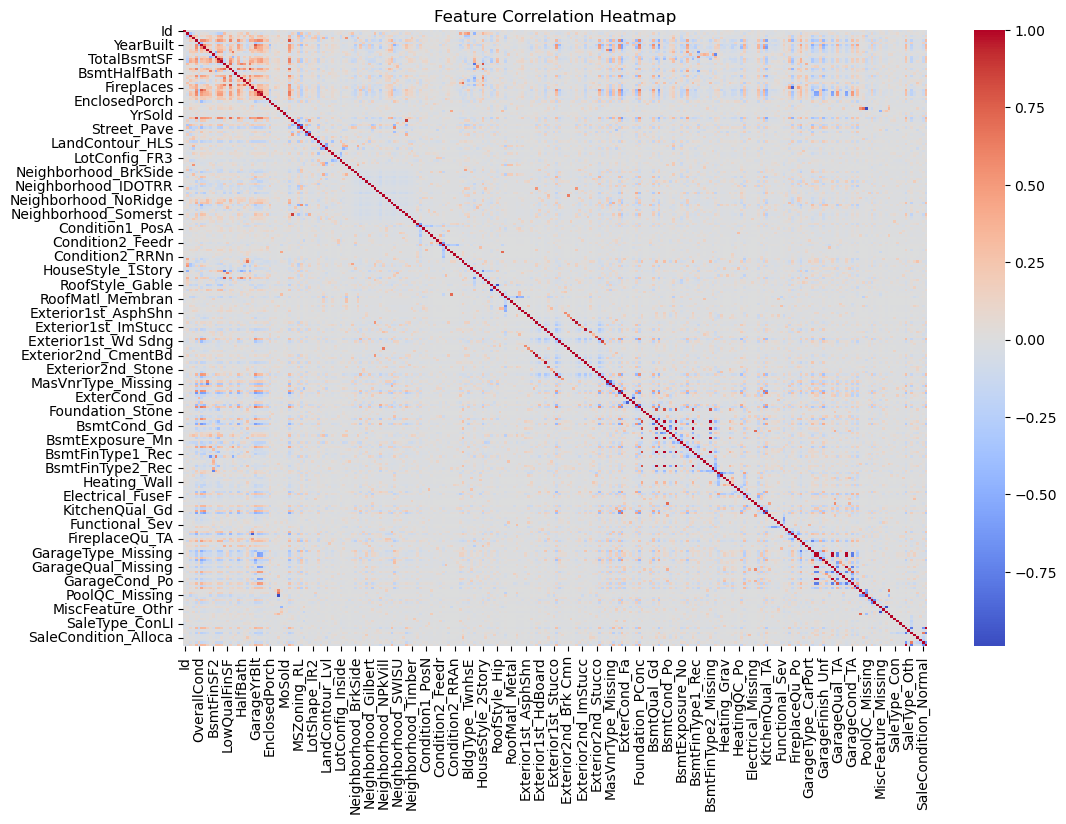

In [7]:
# correlation heatmap to check for multicollinearity

import seaborn as sns
import matplotlib.pyplot as plt

# computing correlation matrix
corr_matrix = df.corr()

# sorting correlated pairs from most to least correlated 
high_corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)

# removing self-correlations 
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]

# setting |0.6| as the threshold from strong correlations 
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.6]

num_high_corr_pairs = high_corr_pairs.shape[0] // 2 # each pair appears twice, so divide by 2

print("Highly Correlated Feature Pairs (>|0.6|):")
print(high_corr_pairs)

# getting set of individual features are in high correlation pairs by
# creating set of the first features from each correlated pair, and a set of the second features,
# then creating a union of both sets for all unique features
unique_high_corr_features = set(high_corr_pairs.index.get_level_values(0)) | set(high_corr_pairs.index.get_level_values(1))

# counting unique high-correlation features
num_unique_features = len(unique_high_corr_features)

print(f"Total number of unique features with high correlations: {num_unique_features}")

# plotting heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

As seen in the above correlation matrix and heatmap, **110 features in this dataset exhibit high multicollinearity,** meaning they are strongly correlated with each other. This can cause Ordinary Least Squares (OLS) regression to assign unstable or inflated coefficients, leading to overfitting and unreliable predictions.

To address this, I will use Ridge Regression, which applies L2 regularization to penalize large coefficients and improve model stability, ensuring better generalization to unseen data.

#### Training Ridge Regression ####

3 steps: 
 1. Train a baseline model with alpha=1.0
 2. Cross-validate to find the best alpha
 3. Train regression with the best alpha

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np


# defining features (Xs) and target (y)
X_train = df.drop(columns=["SalePrice"]) # dropping target variable
y_train = df["SalePrice"] # target variable

# initializing baseline Ridge Reg. model with alpha = 1.0 
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# predict on training set 
y_train_pred = ridge_model.predict(X_train)

# Evaluate RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Baseline Ridge Regression RMSE (alpha=1.0): {rmse:.4f}")

Baseline Ridge Regression RMSE (alpha=1.0): 20545.2565


Cross validating alphas to minimize RMSE:

Process:
- 1. define range of alpha values to test
- 2. use cross-validation to evaluate RMSE for each alpha
- 3. find alpha that gives lowest RMSE


In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np

# defining range of alpha values (logarithmically placed)
alpha_values = np.logspace(-3,3,10) # test values from 0.001 to 1000
best_alpha = None
best_rmse = float('inf') 

# iterating over each alpha value to perform 5-fold cross-validation
for alpha in alpha_values: 
    ridge = Ridge(alpha=alpha)

    # computing RMSE through 5-fold cross-validation
    rmse = -np.mean(cross_val_score(ridge, X_train, y_train,
                                    scoring='neg_root_mean_squared_error', cv=5))
    
    print(f"Alpha: {alpha:.4f}, RMSE: {rmse:.4f}")

    

Alpha: 0.0010, RMSE: 42208.3881
Alpha: 0.0046, RMSE: 42193.5517
Alpha: 0.0215, RMSE: 42126.8232
Alpha: 0.1000, RMSE: 41854.1938
Alpha: 0.4642, RMSE: 40981.9272
Alpha: 2.1544, RMSE: 38934.4599
Alpha: 10.0000, RMSE: 35817.1934
Alpha: 46.4159, RMSE: 33309.6495
Alpha: 215.4435, RMSE: 31804.4905
Alpha: 1000.0000, RMSE: 32545.4824
